## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models

## Load Dataset

In [2]:
dataset_path = Path("../dataset")
dl_data_path = dataset_path / "dl_data"

X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

===== Datasets loaded successfully. =====
X_train: (5969, 9000)
X_validation: (1279, 9000)
X_test: (1280, 9000)
y_train: (5969,)
y_validation: (1279,)
y_test: (1280,)


## Preprocessing & Normalization

In [3]:
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Calculate statistics only from training data
train_mean = X_train.mean()
train_std = X_train.std()

# Normalize
X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Add Channel Dimension

In [4]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== HYBRID CNN-TRANSFORMER INPUT SHAPES =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== HYBRID CNN-TRANSFORMER INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## CNN Residual Feature Extraction Block

In [5]:
def cnn_residual_block(
    x,
    filters,
    kernel_size=7,
    stride=1,
    dropout=0.1
):
    
    shortcut = x

    # First convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=stride,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Second convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=1,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)

    # Match shortcut dimensions if necessary
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(
            filters=filters,
            kernel_size=1,
            strides=stride,
            padding="same"
        )(shortcut)

        shortcut = layers.BatchNormalization()(shortcut)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    x = layers.Dropout(dropout)(x)

    return x

## Transformer Encoder Block

In [6]:
def transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
):
    
    # Multi-Head Self Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    # Residual connection
    x = layers.Add()([
        x,
        attention_output
    ])

    # Layer Normalization
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    # Feed Forward Network
    ff_output = layers.Dense(
        ff_dim,
        activation="gelu"
    )(x)

    ff_output = layers.Dropout(
        dropout
    )(ff_output)

    ff_output = layers.Dense(
        x.shape[-1]
    )(ff_output)

    # Residual connection
    x = layers.Add()([
        x,
        ff_output
    ])

    # Layer Normalization
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x

## Positional Embedding

In [7]:
class PositionalEmbedding(layers.Layer):

    def __init__(
        self,
        sequence_length,
        embedding_dim,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.sequence_length = sequence_length
        self.embedding_dim = embedding_dim

        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=embedding_dim
        )

    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        positions = self.position_embedding(
            positions
        )

        return inputs + positions

    def get_config(self):

        config = super().get_config()

        config.update({
            "sequence_length": self.sequence_length,
            "embedding_dim": self.embedding_dim
        })

        return config

## Build Hybrid CNN-Transformer Model

In [8]:
inputs = layers.Input(
    shape=(9000, 1)
)

x = inputs


# =========================================================
# CNN FRONTEND
# =========================================================

# Initial convolution
x = layers.Conv1D(
    filters=64,
    kernel_size=15,
    strides=2,
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)


# =========================================================
# CNN RESIDUAL BLOCK 1
# =========================================================

x = cnn_residual_block(
    x,
    filters=64,
    kernel_size=7,
    stride=1,
    dropout=0.1
)


# =========================================================
# CNN RESIDUAL BLOCK 2
# =========================================================

x = cnn_residual_block(
    x,
    filters=128,
    kernel_size=7,
    stride=2,
    dropout=0.1
)


# =========================================================
# CNN RESIDUAL BLOCK 3
# =========================================================

x = cnn_residual_block(
    x,
    filters=128,
    kernel_size=5,
    stride=2,
    dropout=0.1
)


# =========================================================
# CNN RESIDUAL BLOCK 4
# =========================================================

x = cnn_residual_block(
    x,
    filters=128,
    kernel_size=5,
    stride=2,
    dropout=0.1
)


# =========================================================
# TEMPORAL PROJECTION
# =========================================================

x = layers.Conv1D(
    filters=128,
    kernel_size=3,
    strides=2,
    padding="same"
)(x)

x = layers.LayerNormalization(
    epsilon=1e-6
)(x)


# =========================================================
# POSITIONAL EMBEDDING
# =========================================================

# After the CNN frontend:
#
# 9000
#  ↓ stride 2
# 4500
#  ↓ stride 2
# 2250
#  ↓ stride 2
# 1125
#  ↓ stride 2
# approximately 563
#
# Final temporal representation ≈ 563 tokens

sequence_length = int(x.shape[1])
embedding_dim = int(x.shape[2])

x = PositionalEmbedding(
    sequence_length=sequence_length,
    embedding_dim=embedding_dim
)(x)


# =========================================================
# TRANSFORMER ENCODER BLOCK 1
# =========================================================

x = transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
)


# =========================================================
# TRANSFORMER ENCODER BLOCK 2
# =========================================================

x = transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
)


# =========================================================
# TRANSFORMER ENCODER BLOCK 3
# =========================================================

x = transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
)


# =========================================================
# GLOBAL TEMPORAL POOLING
# =========================================================

x = layers.GlobalAveragePooling1D()(x)


# =========================================================
# CLASSIFICATION HEAD
# =========================================================

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dropout(
    0.2
)(x)


# =========================================================
# OUTPUT
# =========================================================

outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


# =========================================================
# CREATE MODEL
# =========================================================

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Hybrid_CNN_Transformer"
)

model.summary()

Model: "Hybrid_CNN_Transformer"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 4500, 64)     1024        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 4500, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 4500, 64)     0           ['batch_norm

## Compile Model

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Callbacks

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_hybrid_cnn_transformer_unweighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


## Train Model

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=50,
    batch_size=8,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
747/747 [==============================] - ETA: 0s - loss: 1.0283 - accuracy: 0.5890
Epoch 1: val_loss improved from inf to 0.99656, saving model to best_hybrid_cnn_transformer_unweighted.keras
747/747 [==============================] - 104s 115ms/step - loss: 1.0283 - accuracy: 0.5890 - val_loss: 0.9966 - val_accuracy: 0.5950
Epoch 2/50
747/747 [==============================] - ETA: 0s - loss: 1.0118 - accuracy: 0.5939
Epoch 2: val_loss improved from 0.99656 to 0.99360, saving model to best_hybrid_cnn_transformer_unweighted.keras
747/747 [==============================] - 85s 114ms/step - loss: 1.0118 - accuracy: 0.5939 - val_loss: 0.9936 - val_accuracy: 0.5950
Epoch 3/50
746/747 [============================>.] - ETA: 0s - loss: 1.0024 - accuracy: 0.5940
Epoch 3: val_loss did not improve from 0.99360
747/747 [==============================] - 85s 114ms/step - loss: 1.0024 - accuracy: 0.5939 - val_loss: 0.9992 - val_accuracy: 0.5950
Epoch 4/50
747/747 [====================

## Test Evaluation

In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== HYBRID CNN-TRANSFORMER TEST RESULTS =====")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 11s 238ms/step - loss: 0.9811 - accuracy: 0.5953
===== HYBRID CNN-TRANSFORMER TEST RESULTS =====
Test Loss: 0.9811
Test Accuracy: 0.5953


## Predictions & Confusion Matrix

In [13]:
from sklearn.metrics import confusion_matrix

y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("===== HYBRID CNN-TRANSFORMER CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 9s 175ms/step
===== HYBRID CNN-TRANSFORMER CONFUSION MATRIX =====
[[762   0   0   0]
 [113   0   0   0]
 [363   0   0   0]
 [ 40   0   2   0]]


## Plot Confusion Matrix

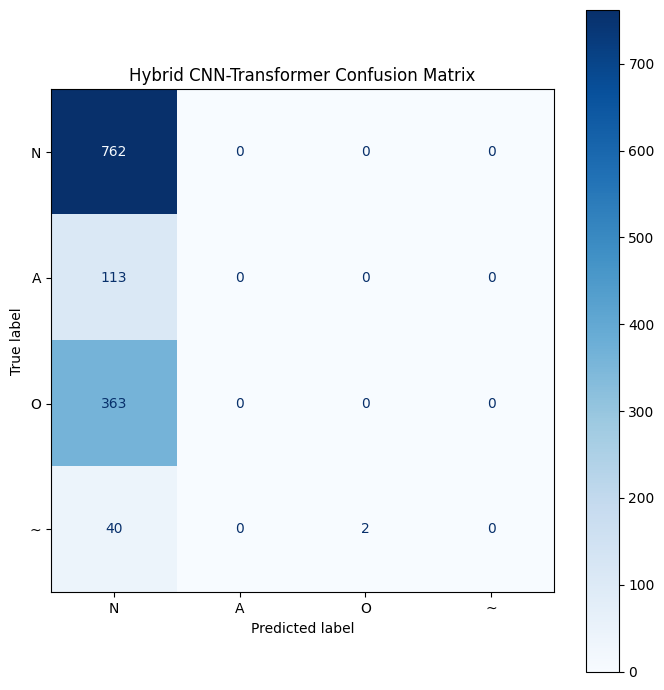

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

class_names = [
    "N",
    "A",
    "O",
    "~"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Hybrid CNN-Transformer Confusion Matrix"
)

plt.tight_layout()
plt.show()

## Classification Report

In [20]:
from sklearn.metrics import classification_report

print("===== HYBRID CNN-TRANSFORMER CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== HYBRID CNN-TRANSFORMER CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.5962    1.0000    0.7471       762
           A     0.0000    0.0000    0.0000       113
           O     0.0000    0.0000    0.0000       363
           ~     0.0000    0.0000    0.0000        42

    accuracy                         0.5953      1280
   macro avg     0.1491    0.2500    0.1868      1280
weighted avg     0.3550    0.5953    0.4447      1280



c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\.venv_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\.venv_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\.venv_gpu\lib\site-packages\sklear

## Loss Curve

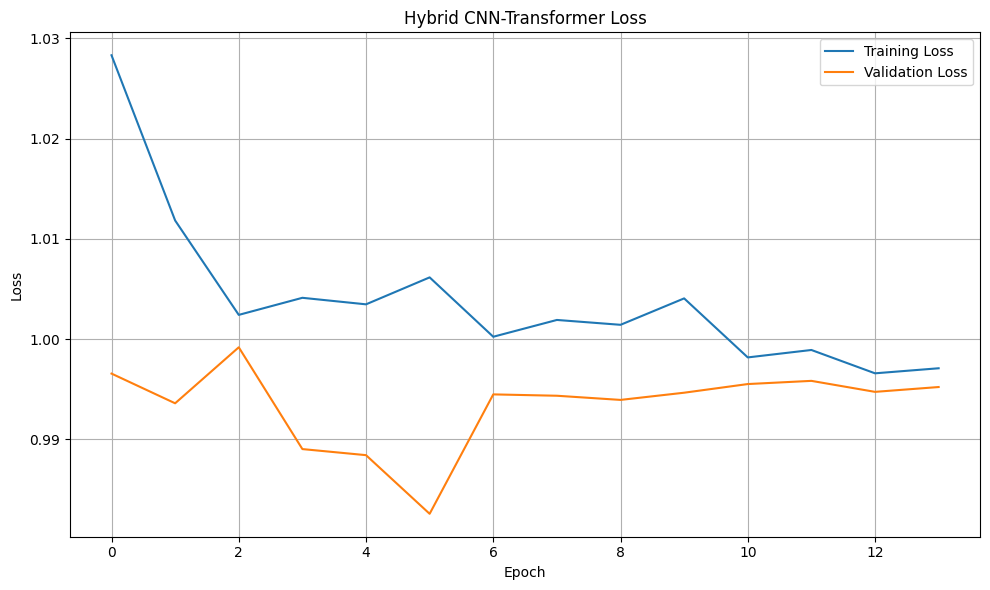

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Hybrid CNN-Transformer Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

## Accuracy Curve

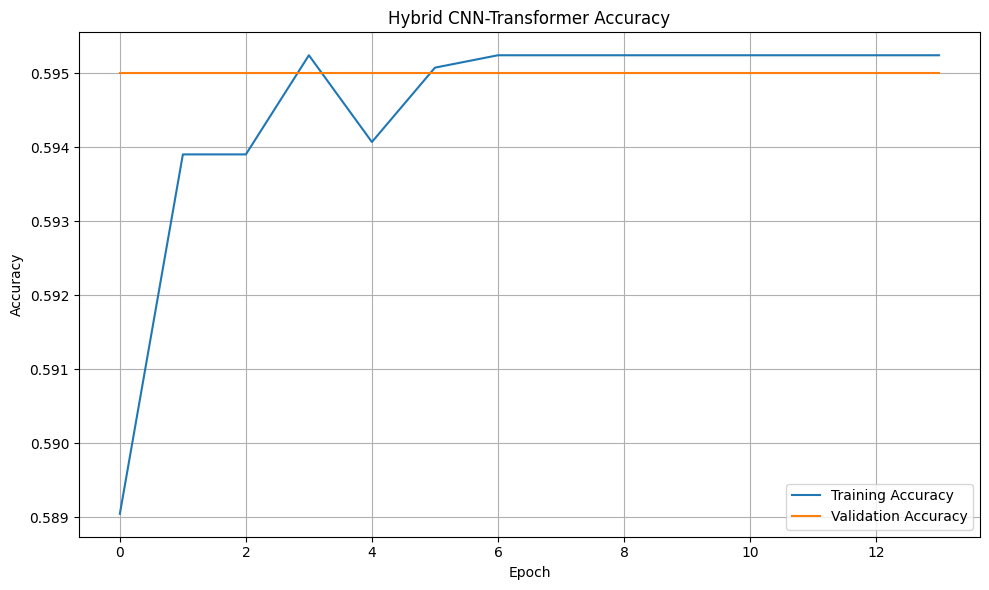

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Hybrid CNN-Transformer Accuracy"
)

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

## Final Test Metrics

In [18]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n==========================================")
print("       HYBRID CNN-TRANSFORMER FINAL RESULTS")
print("==========================================")

print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

print("==========================================")


       HYBRID CNN-TRANSFORMER FINAL RESULTS
Test Loss       : 0.9811
Test Accuracy   : 0.5953
Macro Precision : 0.1491
Macro Recall    : 0.2500
Macro F1        : 0.1868
Weighted F1     : 0.4447
